In [165]:
#import libraries
import numpy as np
import pandas as pd
import plotly.express as px
import ast
import plotly.figure_factory as ff

In [166]:
df = pd.read_csv("jiji_housing_raw.csv")
df.head(10)

,title,region,region_name,region_parent_name,price,is_boost,property_size,bedrooms,bathrooms,furnishing
0,4bdrm Duplex in Benin City for sale,"Edo State, Benin City",Benin City,Edo State,280000000.0,premium,1800.0,4.0,2.0,Unfurnished
1,"Furnished 4bdrm Duplex in Idado, Lekki Phase1 ...","Lekki, Lekki Phase 1",Lekki Phase 1,Lekki,250000000.0,enterprise,500.0,4.0,4.0,Furnished
2,"3bdrm Bungalow in Abijo Oluwa, Ajah for sale","Lagos State, Ajah",Ajah,Lagos State,10000000.0,vip_gold,350.0,3.0,3.0,Semi-Furnished
3,"Furnished 3bdrm Block of Flats in Abijo, Labor...","Lagos State, Ajah",Ajah,Lagos State,56000000.0,vip_gold,650.0,3.0,3.0,Furnished
4,"Furnished 4bdrm Duplex in Ikota Gra, Lekki for...","Lagos State, Lekki",Lekki,Lagos State,140000000.0,vip_gold,180.0,4.0,4.0,Furnished
5,"3bdrm Bungalow in Abijo Gra Ext, Ajah for sale","Lagos State, Ajah",Ajah,Lagos State,65000000.0,vip_gold,650.0,3.0,3.0,Unfurnished
6,2bdrm Bungalow in Ita Oluwo for sale,"Ikorodu, Ita Oluwo",Ita Oluwo,Ikorodu,17000000.0,False,3345.0,2.0,3.0,Unfurnished
7,"Furnished 3bdrm Block of Flats in Abijo Gra, A...","Lagos State, Ajah",Ajah,Lagos State,48000000.0,vip_gold,330.0,3.0,3.0,Furnished
8,Furnished 2bdrm Block of Flats in Beside Mayfa...,"Lagos State, Ajah",Ajah,Lagos State,95000000.0,vip_gold,650.0,2.0,2.0,Furnished
9,Furnished 4bdrm Duplex in Victory Villa Estate...,"Lagos State, Ajah",Ajah,Lagos State,180000000.0,vip_gold,650.0,4.0,4.0,Furnished


In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               1985 non-null   object 
 1   region              1985 non-null   object 
 2   region_name         1985 non-null   object 
 3   region_parent_name  1984 non-null   object 
 4   price               1985 non-null   float64
 5   is_boost            1985 non-null   object 
 6   property_size       1956 non-null   float64
 7   bedrooms            1985 non-null   float64
 8   bathrooms           1985 non-null   float64
 9   furnishing          1985 non-null   object 
dtypes: float64(4), object(6)
memory usage: 155.2+ KB


In [168]:
#missing values
df.isnull().sum()

title                  0
region                 0
region_name            0
region_parent_name     1
price                  0
is_boost               0
property_size         29
bedrooms               0
bathrooms              0
furnishing             0
dtype: int64

In [169]:
#handle missing values
df = df.dropna(subset=["region_parent_name", "property_size"])

In [170]:
#missing values 
df.isnull().sum()

title                 0
region                0
region_name           0
region_parent_name    0
price                 0
is_boost              0
property_size         0
bedrooms              0
bathrooms             0
furnishing            0
dtype: int64

In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1955 entries, 0 to 1984
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               1955 non-null   object 
 1   region              1955 non-null   object 
 2   region_name         1955 non-null   object 
 3   region_parent_name  1955 non-null   object 
 4   price               1955 non-null   float64
 5   is_boost            1955 non-null   object 
 6   property_size       1955 non-null   float64
 7   bedrooms            1955 non-null   float64
 8   bathrooms           1955 non-null   float64
 9   furnishing          1955 non-null   object 
dtypes: float64(4), object(6)
memory usage: 168.0+ KB


In [172]:
#convert the price
df['price'] = (
    df['price']
    .astype(str)
    .str.replace('₦', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [173]:
#outliers prices
df['price'].describe()

count    1.955000e+03
mean     3.912061e+08
std      7.632070e+08
min      1.300000e+06
25%      1.100000e+08
50%      2.000000e+08
75%      3.800000e+08
max      1.500000e+10
Name: price, dtype: float64

In [174]:
#removing outliers
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower) & (df['price'] <= upper)]

In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1775 entries, 0 to 1984
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               1775 non-null   object 
 1   region              1775 non-null   object 
 2   region_name         1775 non-null   object 
 3   region_parent_name  1775 non-null   object 
 4   price               1775 non-null   float64
 5   is_boost            1775 non-null   object 
 6   property_size       1775 non-null   float64
 7   bedrooms            1775 non-null   float64
 8   bathrooms           1775 non-null   float64
 9   furnishing          1775 non-null   object 
dtypes: float64(4), object(6)
memory usage: 152.5+ KB


In [176]:
#categorical cleaning, standardize
df['region'] = df['region'].str.strip().str.title()
df['region_name'] = df['region_name'].str.strip().str.title()
df['region_parent_name'] = df['region_parent_name'].str.strip().str.title()

In [177]:
#categorical cleaning, convert
df['furnishing'] = df['furnishing'].str.lower()

df['furnishing'] = df['furnishing'].replace({
    'fully furnished': 'Furnished',
    'furnished': 'Furnished',
    'semi furnished': 'Semi-Furnished',
    'semi-furnished': 'Semi-Furnished',
    'unfurnished': 'Unfurnished',
    'not furnished': 'Unfurnished'
})

In [178]:
df.columns

Index(['title', 'region', 'region_name', 'region_parent_name', 'price',
       'is_boost', 'property_size', 'bedrooms', 'bathrooms', 'furnishing'],
      dtype='object')

In [179]:
df['bedrooms'] = pd.to_numeric(df['bedrooms'], errors='coerce')
df['bathrooms'] = pd.to_numeric(df['bathrooms'], errors='coerce')

In [180]:
df['property_size'] = (
    df['property_size']
    .astype(str)
    .str.replace('sqm', '', regex=False)
    .str.strip()
)

df['property_size'] = pd.to_numeric(df['property_size'], errors='coerce')

In [181]:
#remove duplicates
df = df.drop_duplicates()

In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1775 entries, 0 to 1984
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               1775 non-null   object 
 1   region              1775 non-null   object 
 2   region_name         1775 non-null   object 
 3   region_parent_name  1775 non-null   object 
 4   price               1775 non-null   float64
 5   is_boost            1775 non-null   object 
 6   property_size       1775 non-null   float64
 7   bedrooms            1775 non-null   float64
 8   bathrooms           1775 non-null   float64
 9   furnishing          1775 non-null   object 
dtypes: float64(4), object(6)
memory usage: 152.5+ KB


In [183]:
df.head()

,title,region,region_name,region_parent_name,price,is_boost,property_size,bedrooms,bathrooms,furnishing
0,4bdrm Duplex in Benin City for sale,"Edo State, Benin City",Benin City,Edo State,280000000.0,premium,1800.0,4.0,2.0,Unfurnished
1,"Furnished 4bdrm Duplex in Idado, Lekki Phase1 ...","Lekki, Lekki Phase 1",Lekki Phase 1,Lekki,250000000.0,enterprise,500.0,4.0,4.0,Furnished
2,"3bdrm Bungalow in Abijo Oluwa, Ajah for sale","Lagos State, Ajah",Ajah,Lagos State,10000000.0,vip_gold,350.0,3.0,3.0,Semi-Furnished
3,"Furnished 3bdrm Block of Flats in Abijo, Labor...","Lagos State, Ajah",Ajah,Lagos State,56000000.0,vip_gold,650.0,3.0,3.0,Furnished
4,"Furnished 4bdrm Duplex in Ikota Gra, Lekki for...","Lagos State, Lekki",Lekki,Lagos State,140000000.0,vip_gold,180.0,4.0,4.0,Furnished


In [184]:
df.to_csv("jiji_housing_cleaned.csv")

In [185]:
#price analysys
avg_price = df['price'].mean()
print("Average house price in Nigeria:", avg_price)

Average house price in Nigeria: 225519915.49239436


In [186]:
#highest and lowest mean
state_avg_prices = df.groupby('region_parent_name')['price'].mean()

highest_state = state_avg_prices.idxmax()
highest_price = state_avg_prices.max()

lowest_state = state_avg_prices.idxmin()
lowest_price = state_avg_prices.min()

print("State with highest mean property price:", highest_state, "-", highest_price)
print("State with lowest mean property price:", lowest_state, "-", lowest_price)


State with highest mean property price: Wuse - 590000000.0
State with lowest mean property price: Kano State - 5000000.0


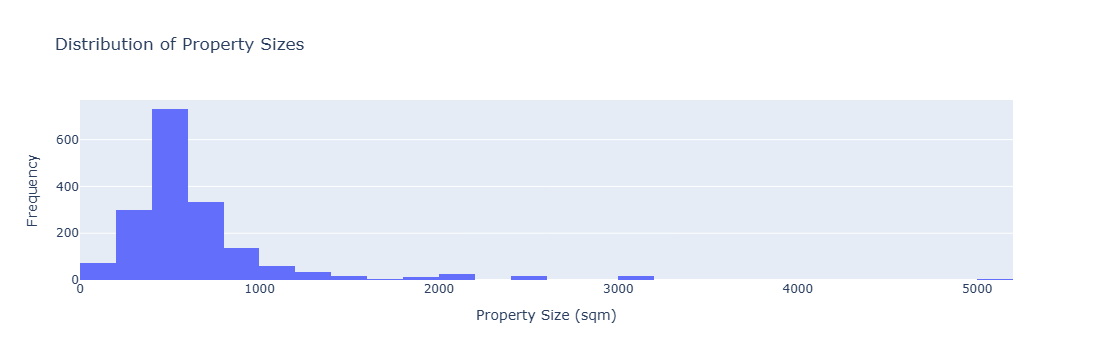

In [187]:
#property size and features
fig = px.histogram(
    df,
    x="property_size",
    nbins=30,
    title="Distribution of Property Sizes"
)

fig.update_layout(
    xaxis_title="Property Size (sqm)",
    yaxis_title="Frequency"
)

fig.show()


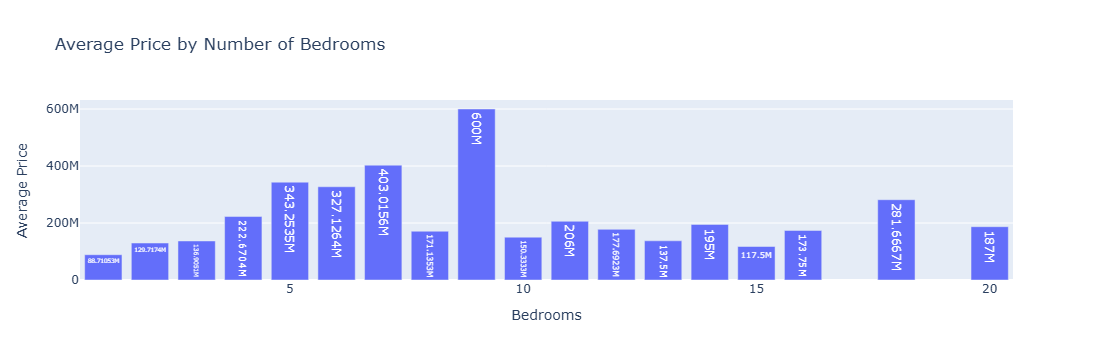

In [188]:

bedroom_price = df.groupby('bedrooms')['price'].mean().reset_index()

fig = px.bar(
    bedroom_price,
    x="bedrooms",
    y="price",
    title="Average Price by Number of Bedrooms",
    labels={"bedrooms": "Bedrooms", "price": "Average Price"},
    text_auto=True  
)

fig.show()


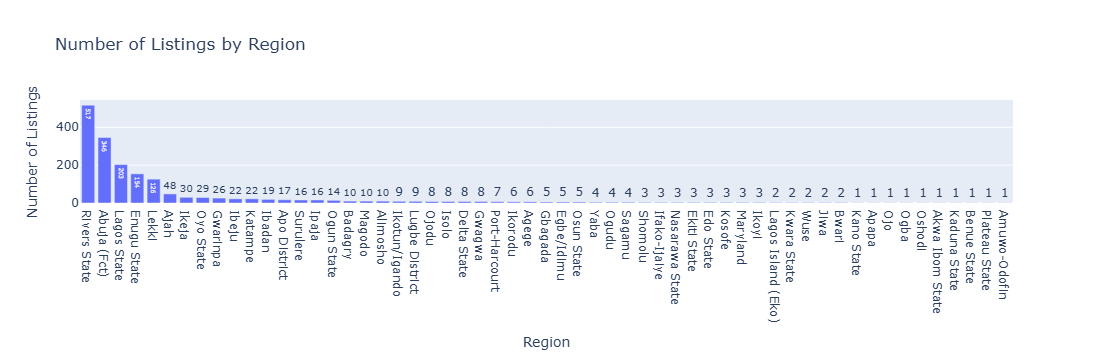

In [189]:

region_counts = df['region_parent_name'].value_counts().reset_index()
region_counts.columns = ['region', 'count']

fig = px.bar(
    region_counts,
    x="region",
    y="count",
    title="Number of Listings by Region",
    labels={"region": "Region", "count": "Number of Listings"},
    text_auto=True  
)

fig.show()


In [190]:
#regional trends
premium = df[df['price'] > df['price'].quantile(0.75)]

premium_regions = premium['region_parent_name'].value_counts()
premium_regions

region_parent_name
Abuja (Fct)      163
Lagos State       49
Lekki             44
Rivers State      44
Ikeja             23
Enugu State       23
Apo District      15
Katampe           14
Magodo             8
Gwagwa             8
Gwarinpa           4
Ajah               4
Surulere           3
Ibeju              3
Ikoyi              3
Ogudu              3
Port-Harcourt      2
Shomolu            2
Agege              2
Isolo              2
Wuse               2
Yaba               1
Ojodu              1
Oshodi             1
Gbagada            1
Maryland           1
Benue State        1
Ekiti State        1
Jiwa               1
Amuwo-Odofin       1
Name: count, dtype: int64

In [191]:
#furnishing analysis

furnishing_avg = df.groupby('furnishing')['price'].mean().reset_index()
furnishing_avg['price'] = furnishing_avg['price'].apply(lambda x: f"{x:,.0f}")
print(furnishing_avg)


       furnishing        price
0       Furnished  221,834,467
1  Semi-Furnished  233,733,047
2     Unfurnished  218,497,180


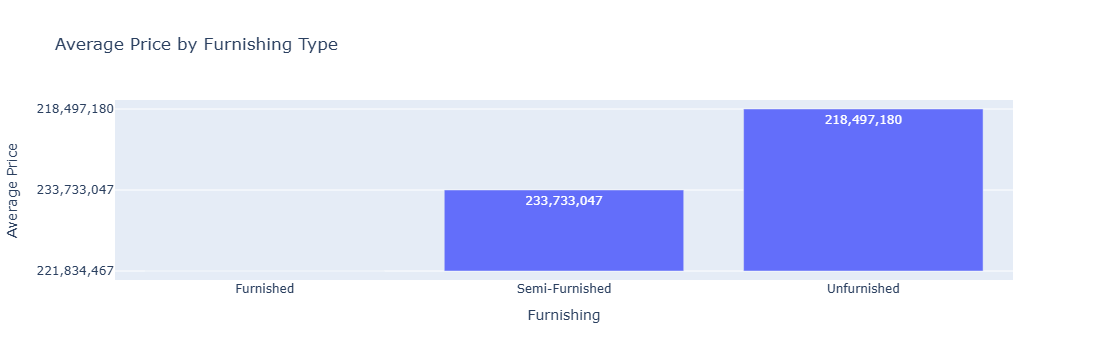

In [192]:
urnishing_avg = df.groupby('furnishing')['price'].mean().reset_index()

fig = px.bar(
    furnishing_avg,
    x="furnishing",
    y="price",
    title="Average Price by Furnishing Type",
    labels={"furnishing": "Furnishing", "price": "Average Price"},
    text_auto=True
)

fig.show()

In [193]:
#listing type
boost_price = df.groupby('is_boost')['price'].mean().reset_index()
boost_price['price'] = boost_price['price'].apply(lambda x: f"{x:,.0f}")
print(boost_price)

     is_boost        price
0       False  170,166,667
1       basic  160,636,364
2     diamond  245,702,703
3  enterprise  228,709,602
4     premium  170,966,667
5         vip   50,750,000
6    vip_gold  176,000,000


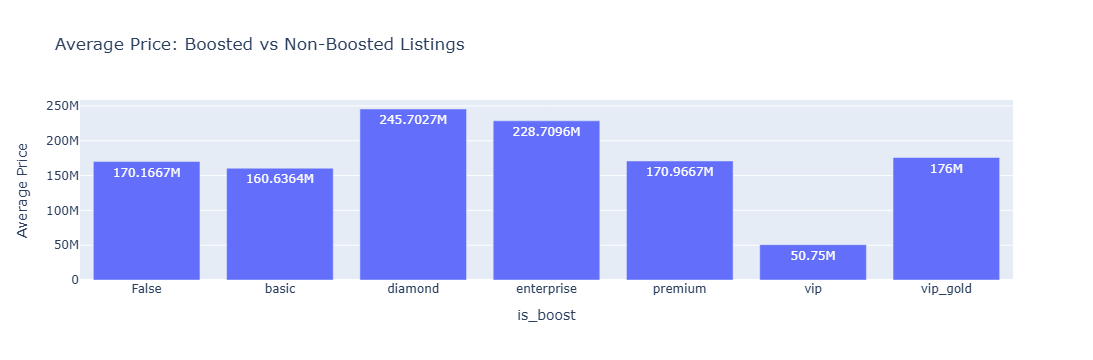

In [194]:

boost_price = df.groupby('is_boost')['price'].mean().reset_index()
fig = px.bar(
    boost_price,
    x="is_boost",
    y="price",
    title="Average Price: Boosted vs Non-Boosted Listings",
    labels={"is_boosted": "Is Boosted", "price": "Average Price"},
    text_auto=True
)

fig.show()


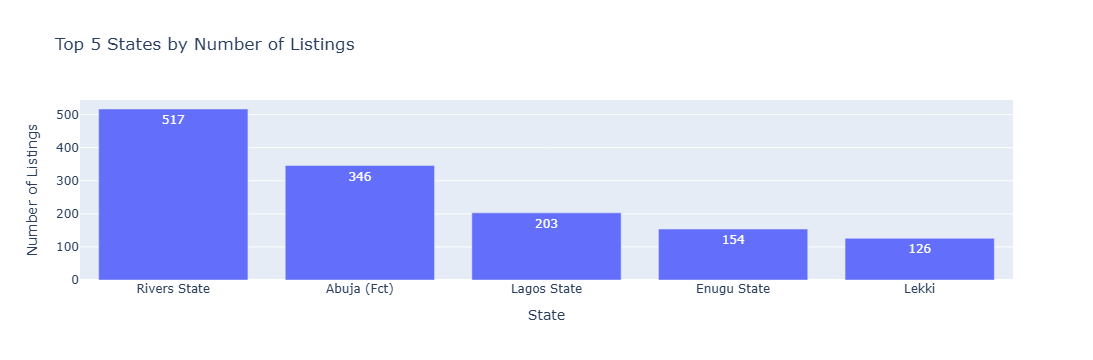

In [195]:
#visualization
top5_states = state_counts.sort_values(by="count", ascending=False).head(5)

fig = px.bar(
    top5_states,
    x="state",
    y="count",
    title="Top 5 States by Number of Listings",
    labels={"state": "State", "count": "Number of Listings"},
    text_auto=True
)
fig.show()


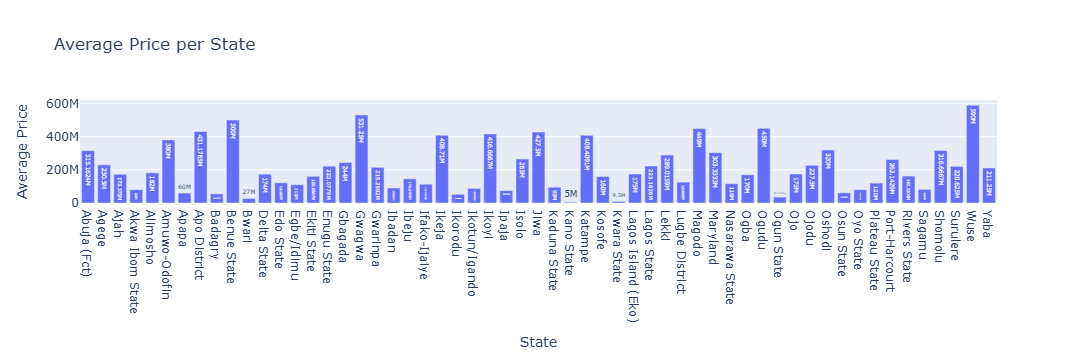

In [196]:
#visualization
state_avg = df.groupby('region_parent_name')['price'].mean().reset_index()

fig = px.bar(
    state_avg,
    x="region_parent_name",
    y="price",
    title="Average Price per State",
    labels={"region_parent_name": "State", "price": "Average Price"},
    text_auto=True
)

fig.show()


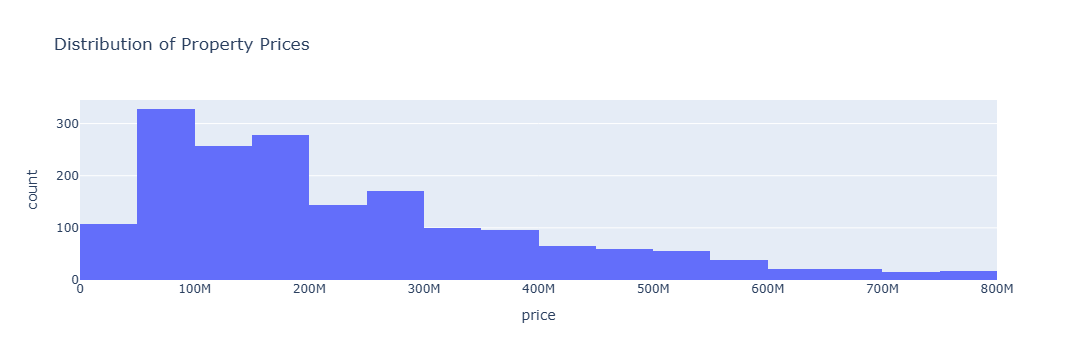

In [197]:
#visualization
fig = px.histogram(
    df,
    x="price",
    nbins=30,
    title="Distribution of Property Prices"
)

fig.show()


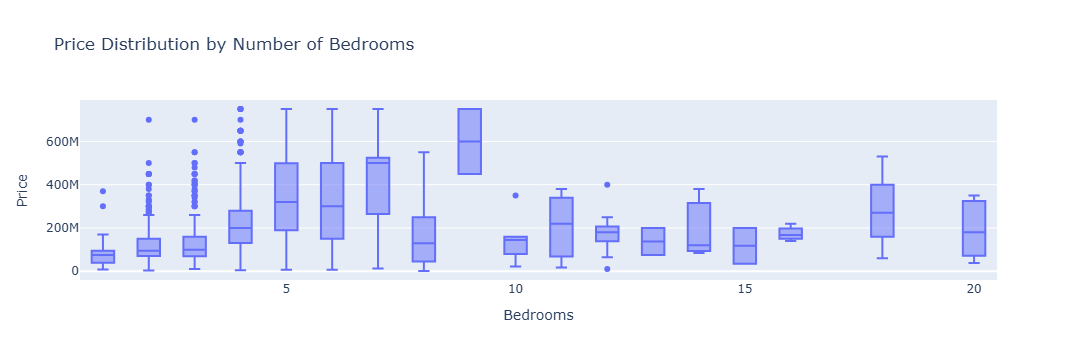

In [198]:
#visualiztion
fig = px.box(
    df,
    x="bedrooms",
    y="price",
    title="Price Distribution by Number of Bedrooms",
    labels={"bedrooms": "Bedrooms", "price": "Price"}
)

fig.show()


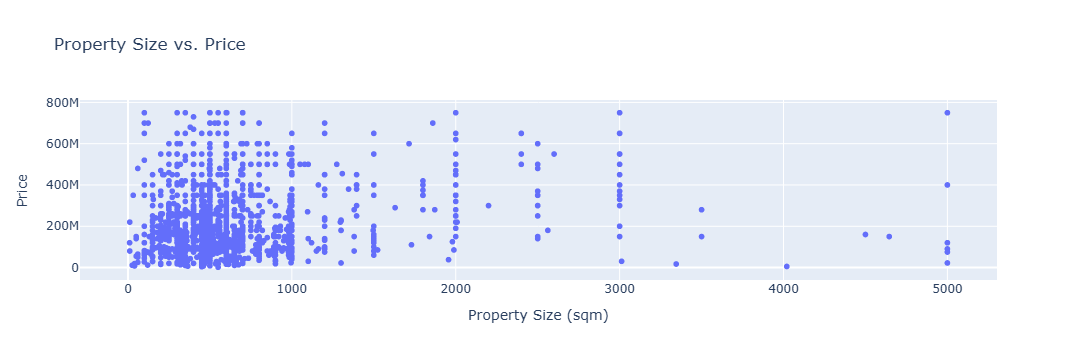

In [199]:
#visualiztion
fig = px.scatter(
    df,
    x="property_size",
    y="price",
    title="Property Size vs. Price",
    labels={"property_size": "Property Size (sqm)", "price": "Price"}
)
fig.show()


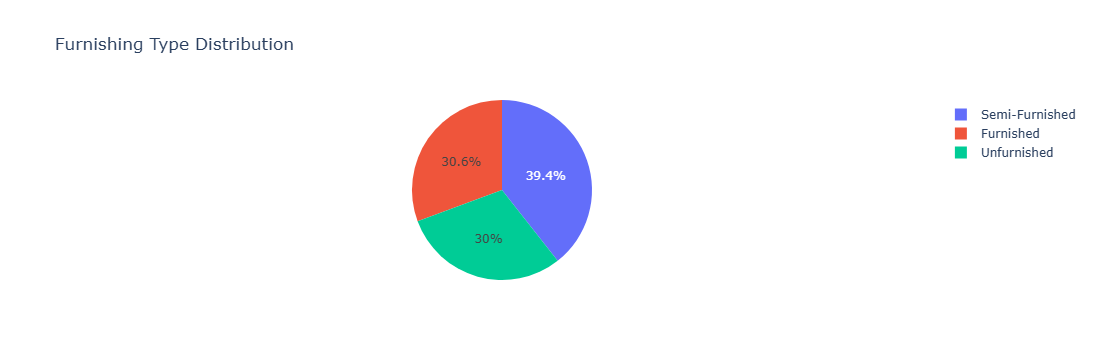

In [200]:
#visualization
fig = px.pie(
    df,
    names="furnishing",
    title="Furnishing Type Distribution"
)
fig.show()


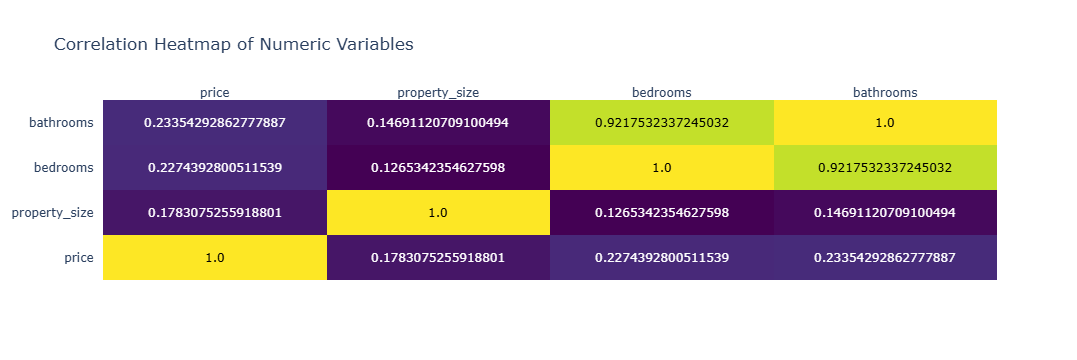

In [201]:
#visualization
numeric_df = df[['price', 'property_size', 'bedrooms', 'bathrooms']].dropna()

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Create heatmap
fig = ff.create_annotated_heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns.tolist(),
    y=corr_matrix.columns.tolist(),
    colorscale="Viridis"
)

fig.update_layout(title="Correlation Heatmap of Numeric Variables")
fig.show()


In [ ]:
#Summary of Findings 
Lagos and Abuja have the highest-priced listings Nigeria.
Kano states and some other sates in the north are the most affordable.
Furnished properties generally cost more due to added value.
Bedrooms and bathrooms have moderate positive relationships with price, indicating that larger
and more feature-rich properties tend to be more expensive.”
Boosted listings are often associated with premium properties.
Larger homes with more bedrooms and bathrooms attract higher prices.
Affordable housing is concentrated in less urbanized states.

In [ ]:
#Business Insights & Recommendations
Furnished properties perform best overall because they command higher prices due to the added value of furniture and amenities.
Lagos and Abuja contribute the most revenue potential because they have the highest-priced listings in Nigeria.
Kano and other northern states are the most affordable, indicating lower revenue potential per listing.
School admission periods for family housing, Pre-holiday periods when people relocate. On Jiji, boosted or premium listings are more likely to appear during these peak periods.
Considering localized promotions and discounts to attract buyers in lower-demand areas.
Highlight key features like number of bedrooms, bathrooms, and furnishing status.